In [8]:
import pandas as pd

# خواندن فایل MICFOAL
df_micfoal = pd.read_csv('Results/MICFOAL_cumulative_accuracy_not_scaled.csv', index_col=0)

# تقسیم تمام مقادیر بر 100
df_micfoal_scaled = df_micfoal / 100

# ذخیره فایل مقیاس شده
df_micfoal_scaled.to_csv('Results/MICFOAL_cumulative_accuracy.csv')

print("فایل MICFOAL با موفقیت تقسیم بر 100 شد و ذخیره شد!")
print("\nنمونه مقادیر قبل و بعد:")
print("قبل:")
print(df_micfoal.iloc[:3, :3])
print("\nبعد (تقسیم بر 100):")
print(df_micfoal_scaled.iloc[:3, :3])

# بررسی بازه مقادیر
print(f"\nبازه مقادیر قبل: [{df_micfoal.min().min():.3f}, {df_micfoal.max().max():.3f}]")
print(f"بازه مقادیر بعد: [{df_micfoal_scaled.min().min():.3f}, {df_micfoal_scaled.max().max():.3f}]")

فایل MICFOAL با موفقیت تقسیم بر 100 شد و ذخیره شد!

نمونه مقادیر قبل و بعد:
قبل:
               1   2          3
Attack Size                    
0              0   0   0.000000
1            100  50  33.333333
3              0   0   0.000000

بعد (تقسیم بر 100):
               1    2         3
Attack Size                    
0            0.0  0.0  0.000000
1            1.0  0.5  0.333333
3            0.0  0.0  0.000000

بازه مقادیر قبل: [0.000, 100.000]
بازه مقادیر بعد: [0.000, 1.000]


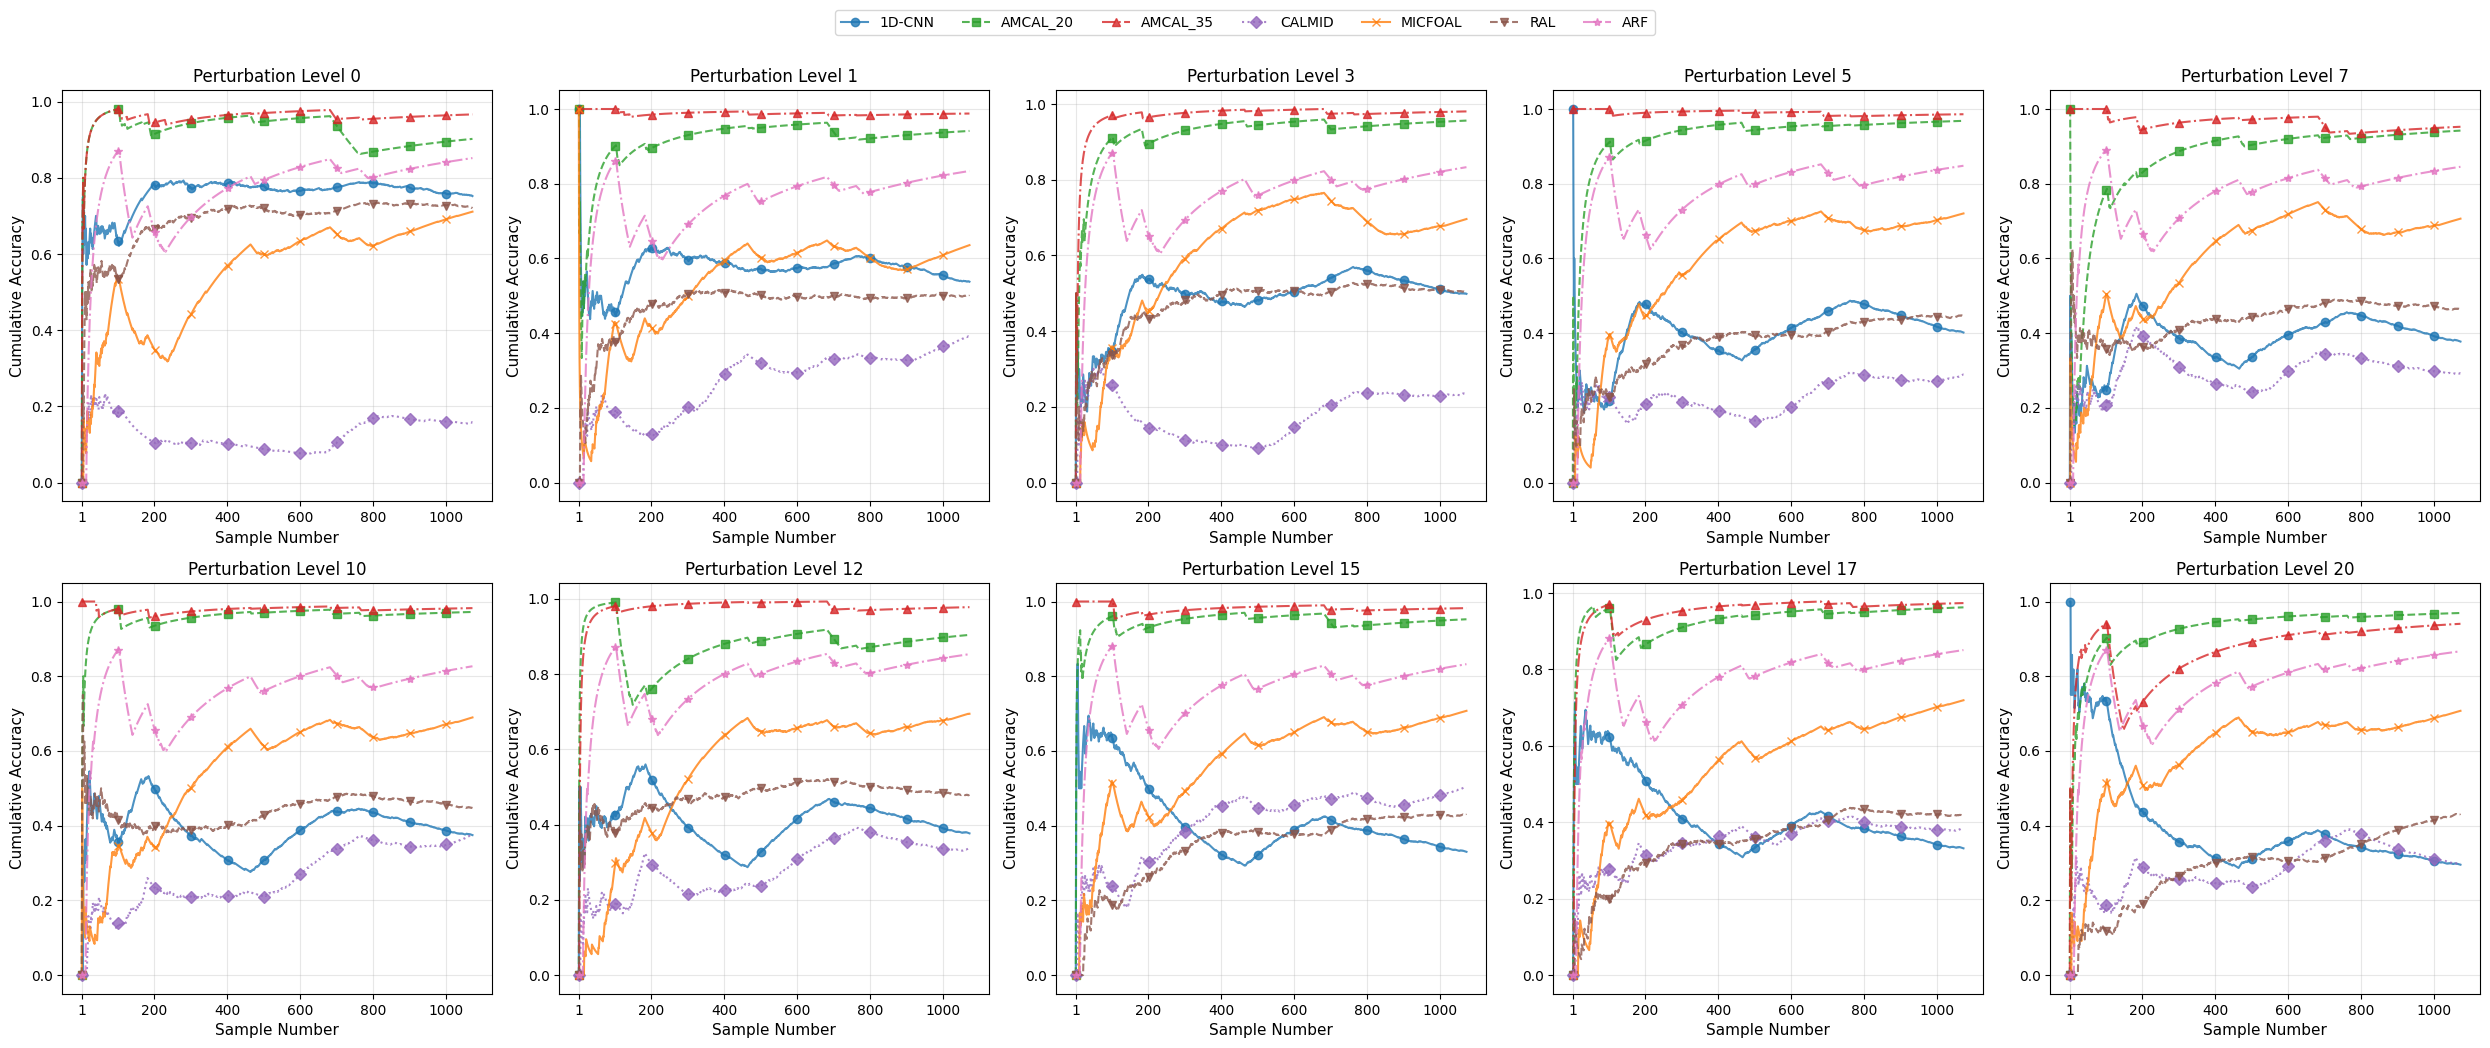

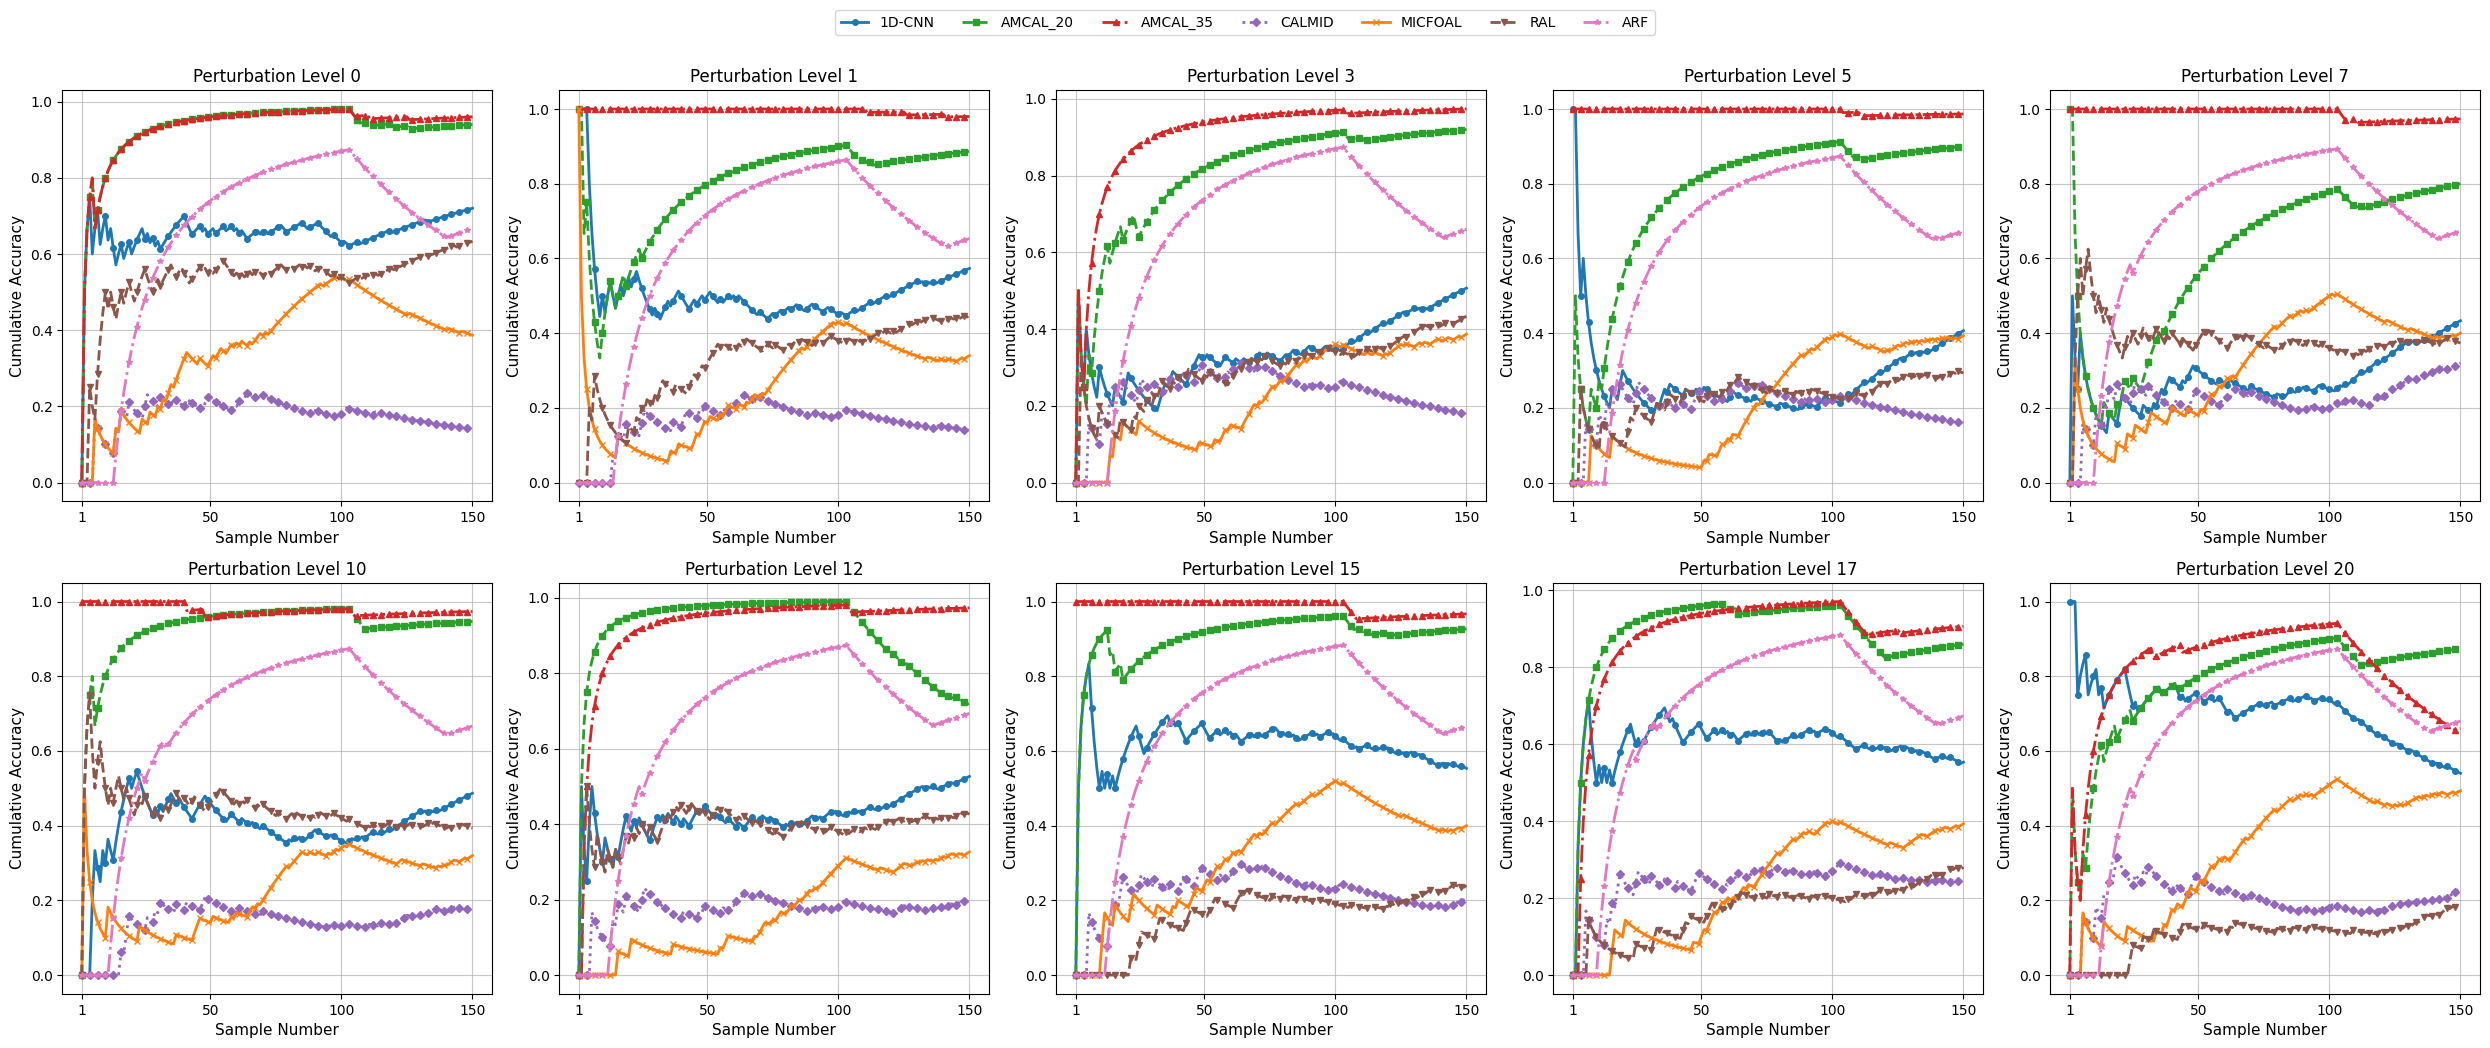

✓ Plots saved:
  - Results/cumulative_accuracy_full_7methods.png
  - Results/cumulative_accuracy_zoom_7methods.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# List of methods and file names (7 methods)
methods = ['1D-CNN','AMCAL_20','AMCAL_35', 'CALMID', 'MICFOAL', 'RAL', 'ARF']
file_names = [f"Results/{method}_cumulative_accuracy.csv" for method in methods]

# Levels
levels = [0, 1, 3, 5, 7, 10, 12, 15, 17, 20]

# **Zoom range**
zoom_start = 1   # Start of zoom range
zoom_end = 150   # End of zoom range

# Read data
data = {}
for method, file_name in zip(methods, file_names):
    df = pd.read_csv(file_name, index_col=0)
    data[method] = df

# Colors and styles (7 DISTINCT colors for 7 methods)
colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#ff7f0e', '#8c564b', '#e377c2']
linestyles = ['-', '--', '-.', ':', '-', '--', '-.']  # Extended for 7
markers = ['o', 's', '^', 'D', 'x', 'v', '*']        # Extended for 7

# Sample numbers
samples = range(1, 1074)

# **Main Figure: Full Range Plots** (2x5 = 10 subplots, 2 empty for 10 levels)
fig_main, axs_main = plt.subplots(2, 5, figsize=(25, 10), sharex=False, sharey=False)
axs_main = axs_main.flatten()

for i, level in enumerate(levels):
    ax = axs_main[i]
    
    # Plot full range (7 methods)
    for j, method in enumerate(methods):
        accuracies = data[method].loc[level].values
        ax.plot(samples, accuracies, color=colors[j], linestyle=linestyles[j], 
                marker=markers[j], markevery=100, linewidth=1.5, alpha=0.8, label=method)
        
    ax.set_title(f'Perturbation Level {level}', fontsize=12)
    ax.set_xlabel('Sample Number', fontsize=11)
    ax.set_ylabel('Cumulative Accuracy', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=10)
    
    # **FORCE numbers on axes**
    ax.set_xticks([1, 200, 400, 600, 800, 1000])
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Hide empty subplots (last 0)
for i in range(len(levels), 10):
    axs_main[i].set_visible(False)

# Add legend to main figure (7 items)
handles, labels = axs_main[0].get_legend_handles_labels()
fig_main.legend(handles, labels, loc='upper center', ncol=7, bbox_to_anchor=(0.5, 1.05), fontsize=10)

plt.tight_layout()
plt.savefig('Results/cumulative_accuracy_full_7methods.png', dpi=300, bbox_inches='tight')
plt.show()

# **Separate Zoom Figure: Zoomed Range Plots**
fig_zoom, axs_zoom = plt.subplots(2, 5, figsize=(25, 10), sharex=False, sharey=False)
axs_zoom = axs_zoom.flatten()

for i, level in enumerate(levels):
    axz = axs_zoom[i]
    
    # Plot zoomed range (7 methods)
    for j, method in enumerate(methods):
        zoom_samples = samples[zoom_start-1:zoom_end]
        zoom_accuracies = data[method].loc[level].values[zoom_start-1:zoom_end]
        axz.plot(zoom_samples, zoom_accuracies, color=colors[j], 
                 linestyle=linestyles[j], marker=markers[j], 
                 markersize=4, linewidth=2, markevery=3, alpha=1, label=method)
    
    axz.set_title(f'Perturbation Level {level}', fontsize=12)
    axz.set_xlabel('Sample Number', fontsize=11)
    axz.set_ylabel('Cumulative Accuracy', fontsize=11)
    axz.grid(True, alpha=0.7)
    axz.tick_params(labelsize=10)
    
    # **FORCE numbers on axes for ZOOM**
    axz.set_xticks([zoom_start, 50, 100, zoom_end])
    axz.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Hide empty subplots
for i in range(len(levels), 10):
    axs_zoom[i].set_visible(False)

# Add legend to zoom figure (7 items)
handles_zoom, labels_zoom = axs_zoom[0].get_legend_handles_labels()
fig_zoom.legend(handles_zoom, labels_zoom, loc='upper center', ncol=7, bbox_to_anchor=(0.5, 1.05), fontsize=10)

plt.tight_layout()
plt.savefig('Results/cumulative_accuracy_zoom_7methods.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plots saved:")
print("  - Results/cumulative_accuracy_full_7methods.png")
print("  - Results/cumulative_accuracy_zoom_7methods.png")

## 8 Method

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ========================
# Function to ensure minimum length by copying last rows
# ========================
def extend_to_length(df_row, target_length=1073):
    """
    Extends a pandas Series (single row) to target_length by copying the last values.
    If already long enough, returns original (trimmed to target_length if too long).
    """
    if len(df_row) >= target_length:
        return df_row.iloc[:target_length]
    else:
        current_len = len(df_row)
        last_value = df_row.iloc[-1]
        # Calculate how many copies needed
        repeats = target_length - current_len
        # Create extended array: original + repeated last value
        extended = np.concatenate([df_row.values, [last_value] * repeats])
        return pd.Series(extended)

# ========================
# List of methods and file names (8 methods including AF)
# ========================
methods = ['1D-CNN', 'AMCAL_20', 'AMCAL_35', 'CALMID', 'MICFOAL', 'RAL', 'ARF', 'AF']
file_names = [f"Results/{method}_cumulative_accuracy.csv" for method in methods]

# Levels
levels = [0, 1, 3, 5, 7, 10, 12, 15, 17, 20]

# Zoom range
zoom_start = 1
zoom_end = 150

# Read data and extend if necessary
data = {}
for method, file_name in zip(methods, file_names):
    df = pd.read_csv(file_name, index_col=0)
    # Apply extension to each row (each perturbation level)
    df_extended = df.apply(lambda row: extend_to_length(row, target_length=1073), axis=1)
    data[method] = df_extended

# Colors and styles (8 distinct)
colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#ff7f0e', '#8c564b', '#e377c2', '#17becf']
linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':']
markers = ['o', 's', '^', 'D', 'x', 'v', '*', 'P']

# Sample numbers (now guaranteed length 1073)
samples = range(1, 1074)

# ========================
# Main Figure: Full Range (2x5 subplots)
# ========================
fig_main, axs_main = plt.subplots(2, 5, figsize=(25, 10), sharex=False, sharey=False)
axs_main = axs_main.flatten()

for i, level in enumerate(levels):
    ax = axs_main[i]
    
    for j, method in enumerate(methods):
        accuracies = data[method].loc[level].values
        ax.plot(samples, accuracies, color=colors[j], linestyle=linestyles[j],
                marker=markers[j], markevery=100, linewidth=1.5, alpha=0.8, label=method)
    
    ax.set_title(f'Perturbation Level {level}', fontsize=12)
    ax.set_xlabel('Sample Number', fontsize=11)
    ax.set_ylabel('Cumulative Accuracy', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=10)
    ax.set_xticks([1, 200, 400, 600, 800, 1000])
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Hide empty subplots (if less than 10 levels)
for i in range(len(levels), 10):
    axs_main[i].set_visible(False)

handles, labels = axs_main[0].get_legend_handles_labels()
fig_main.legend(handles, labels, loc='upper center', ncol=8, bbox_to_anchor=(0.5, 1.05), fontsize=10)

plt.tight_layout()
plt.savefig('Results/cumulative_accuracy_full_8methods.png', dpi=300, bbox_inches='tight')
plt.show()

# ========================
# Zoom Figure (first 150 samples)
# ========================
fig_zoom, axs_zoom = plt.subplots(2, 5, figsize=(25, 10), sharex=False, sharey=False)
axs_zoom = axs_zoom.flatten()

for i, level in enumerate(levels):
    axz = axs_zoom[i]
    
    for j, method in enumerate(methods):
        # Ensure zoom range exists (data length is at least zoom_end)
        full_acc = data[method].loc[level].values
        # If for any reason still shorter, extend to zoom_end
        if len(full_acc) < zoom_end:
            last_val = full_acc[-1]
            full_acc = np.concatenate([full_acc, [last_val] * (zoom_end - len(full_acc))])
        
        zoom_samples = samples[:zoom_end]
        zoom_accuracies = full_acc[:zoom_end]
        axz.plot(zoom_samples, zoom_accuracies, color=colors[j],
                 linestyle=linestyles[j], marker=markers[j],
                 markersize=4, linewidth=2, markevery=3, alpha=1, label=method)
    
    axz.set_title(f'Perturbation Level {level}', fontsize=12)
    axz.set_xlabel('Sample Number', fontsize=11)
    axz.set_ylabel('Cumulative Accuracy', fontsize=11)
    axz.grid(True, alpha=0.7)
    axz.tick_params(labelsize=10)
    axz.set_xticks([zoom_start, 50, 100, zoom_end])
    axz.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

for i in range(len(levels), 10):
    axs_zoom[i].set_visible(False)

handles_zoom, labels_zoom = axs_zoom[0].get_legend_handles_labels()
fig_zoom.legend(handles_zoom, labels_zoom, loc='upper center', ncol=8, bbox_to_anchor=(0.5, 1.05), fontsize=10)

plt.tight_layout()
plt.savefig('Results/cumulative_accuracy_zoom_8methods.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plots saved:")
print("  - Results/cumulative_accuracy_full_8methods.png")
print("  - Results/cumulative_accuracy_zoom_8methods.png")
print("\nNote: Any CSV with fewer than 1073 samples per level was automatically extended by copying the last value.")

## Fast adaptation metrics


🧠 COMPUTING ADAPTATION SPEED METRICS FROM CUMULATIVE ACCURACY

✅ ADAPTATION METRICS SAVED: Results/adaptation_speed_metrics.csv
 Perturbation Level 1D-CNN_Slope 1D-CNN_Severity  1D-CNN_TTA 1D-CNN_Plateau AMCAL_20_Slope AMCAL_20_Severity  AMCAL_20_TTA AMCAL_20_Plateau AMCAL_35_Slope AMCAL_35_Severity  AMCAL_35_TTA AMCAL_35_Plateau CALMID_Slope CALMID_Severity  CALMID_TTA CALMID_Plateau MICFOAL_Slope MICFOAL_Severity  MICFOAL_TTA MICFOAL_Plateau RAL_Slope RAL_Severity  RAL_TTA RAL_Plateau ARF_Slope ARF_Severity  ARF_TTA ARF_Plateau
                  0     0.000934          0.7929        1073         0.7564       0.001074            0.9806             5           0.8998       0.001134            0.9806             5           0.9657     0.000148          0.2344        1073         0.1567      0.000663           0.7111         1073          0.7044  0.000671       0.7346     1073      0.7250  0.000794       0.8738       65      0.8483
                  1    -0.000431          0.5625       

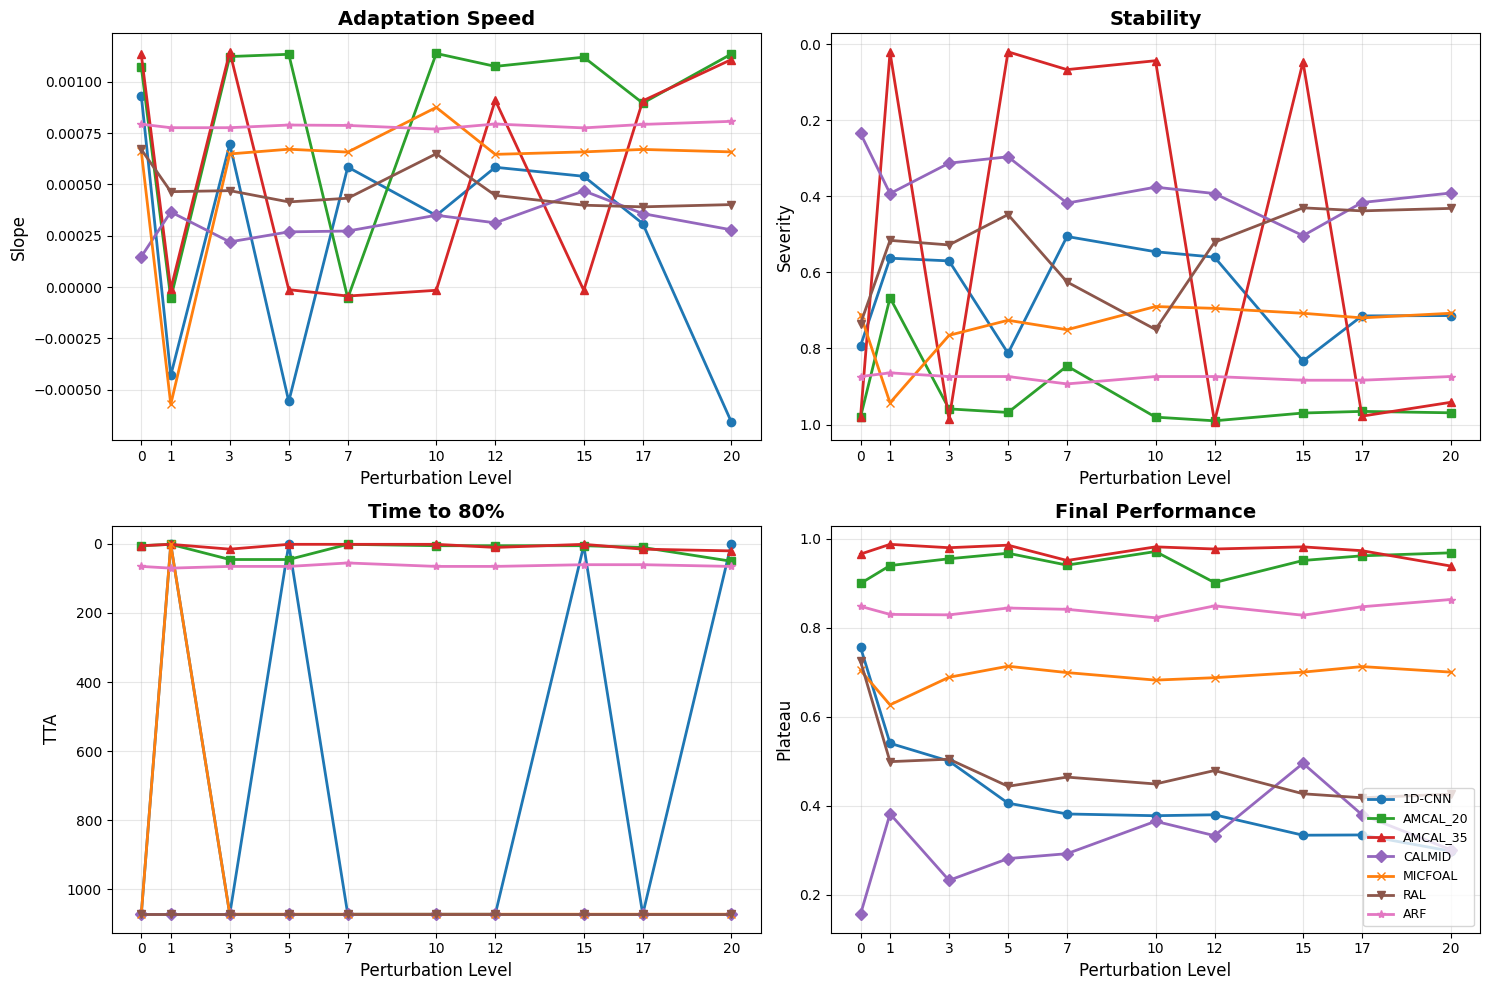


✅ ADAPTATION SPEED PLOT SAVED: Results/adaptation_speed_comparison.png

📊 METRICS EXPLAINED:
🔥 Slope:        Higher = FASTER adaptation
🛡️ Severity:     Lower = MORE STABLE
⚡ TTA:          Lower = QUICKER to 80%
🎯 Plateau:      Higher = BETTER final performance

✅ FILES SAVED:
  - Results/adaptation_speed_metrics.csv
  - Results/best_methods_summary.csv
  - Results/adaptation_speed_comparison.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# List of methods and file names (7 methods)
methods = ['1D-CNN','AMCAL_20','AMCAL_35', 'CALMID', 'MICFOAL', 'RAL', 'ARF']
file_names = [f"Results/{method}_cumulative_accuracy.csv" for method in methods]

# Levels
levels = [0, 1, 3, 5, 7, 10, 12, 15, 17, 20]

# Read data
data = {}
for method, file_name in zip(methods, file_names):
    df = pd.read_csv(file_name, index_col=0)
    data[method] = df

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#ff7f0e', '#8c564b', '#e377c2']
linestyles = ['-', '--', '-.', ':', '-', '--', '-.']
markers = ['o', 's', '^', 'D', 'x', 'v', '*']
samples = range(1, 1074)

# ===========================================
# **ADAPTATION SPEED METRICS**
# ===========================================

print("\n" + "="*80)
print("🧠 COMPUTING ADAPTATION SPEED METRICS FROM CUMULATIVE ACCURACY")
print("="*80)

# **4 Adaptation Metrics Table**
adaptation_results = []

for level in levels:
    level_row = {'Perturbation Level': level}
    
    for method in methods:
        cum_acc = data[method].loc[level].values
        
        # **1. Learning Curve Slope** (سرعت تطبیق)
        slope = np.gradient(cum_acc)
        avg_slope = np.mean(slope)
        
        # **2. Severity** (پایداری)
        severity = np.max(cum_acc) - np.min(cum_acc)
        
        # **3. Time to Threshold (80%)** 
        tta_idx = np.where(cum_acc >= 0.8)[0]
        tta = tta_idx[0] + 1 if len(tta_idx) > 0 else len(cum_acc)
        
        # **4. Final Plateau** (50 نمونه آخر)
        final_plateau = np.mean(cum_acc[-50:])
        
        level_row.update({
            f'{method}_Slope': f"{avg_slope:.6f}",
            f'{method}_Severity': f"{severity:.4f}",
            f'{method}_TTA': tta,
            f'{method}_Plateau': f"{final_plateau:.4f}"
        })
    
    adaptation_results.append(level_row)

# **Save to CSV**
if not os.path.exists('Results'):
    os.makedirs('Results')

df_adaptation = pd.DataFrame(adaptation_results)
df_adaptation.to_csv('Results/adaptation_speed_metrics.csv', index=False)

print("\n✅ ADAPTATION METRICS SAVED: Results/adaptation_speed_metrics.csv")
print(df_adaptation.round(4).to_string(index=False))

# **Summary Table (Best Methods per Metric)**
print("\n" + "="*80)
print("🏆 BEST METHODS BY ADAPTATION SPEED")
print("="*80)

summary_table = []
for level in levels:
    level_data = df_adaptation[df_adaptation['Perturbation Level'] == level].iloc[0]
    
    # Find best for each metric
    best_slope = max(methods, key=lambda m: float(level_data[f'{m}_Slope']))
    best_severity = min(methods, key=lambda m: float(level_data[f'{m}_Severity']))
    best_tta = min(methods, key=lambda m: int(level_data[f'{m}_TTA']))
    best_plateau = max(methods, key=lambda m: float(level_data[f'{m}_Plateau']))
    
    summary_table.append({
        'Level': level,
        'Fastest Slope': best_slope,
        'Most Stable': best_severity,
        'Quickest TTA': best_tta,
        'Best Final': best_plateau
    })

df_summary = pd.DataFrame(summary_table)
print(df_summary.to_string(index=False))
df_summary.to_csv('Results/best_methods_summary.csv', index=False)

# **PLOT: Adaptation Speed Comparison**
fig_speed, axs_speed = plt.subplots(2, 2, figsize=(15, 10))
axs_speed = axs_speed.flatten()

metrics = ['Slope', 'Severity', 'TTA', 'Plateau']
titles = ['Adaptation Speed', 'Stability', 'Time to 80%', 'Final Performance']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axs_speed[i]
    
    for j, method in enumerate(methods):
        values = [float(df_adaptation.loc[k, f'{method}_{metric}']) 
                 for k in range(len(levels))]
        
        if metric == 'TTA':
            values = [int(v) for v in values]  # TTA is integer
        
        ax.plot(levels, values, color=colors[j], marker=markers[j], 
                linewidth=2, label=method, markersize=6)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Perturbation Level', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(levels)
    
    # Invert Severity and TTA (lower is better)
    if metric in ['Severity', 'TTA']:
        ax.invert_yaxis()

axs_speed[3].legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('Results/adaptation_speed_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ ADAPTATION SPEED PLOT SAVED: Results/adaptation_speed_comparison.png")

print("\n" + "="*80)
print("📊 METRICS EXPLAINED:")
print("="*80)
print("🔥 Slope:        Higher = FASTER adaptation")
print("🛡️ Severity:     Lower = MORE STABLE")
print("⚡ TTA:          Lower = QUICKER to 80%")
print("🎯 Plateau:      Higher = BETTER final performance")

print("\n✅ FILES SAVED:")
print("  - Results/adaptation_speed_metrics.csv")
print("  - Results/best_methods_summary.csv") 
print("  - Results/adaptation_speed_comparison.png")

## 

LOADING DATA
✓ Loaded 1D-CNN from Results/1D-CNN_cumulative_accuracy.csv (shape: (10, 1073))
✓ Loaded AMCAL_20 from Results/AMCAL_20_cumulative_accuracy.csv (shape: (10, 1073))
✓ Loaded AMCAL_35 from Results/AMCAL_35_cumulative_accuracy.csv (shape: (10, 1073))
✓ Loaded CALMID from Results/CALMID_cumulative_accuracy.csv (shape: (10, 1073))
✓ Loaded MICFOAL from Results/MICFOAL_cumulative_accuracy.csv (shape: (10, 1073))
✓ Loaded RAL from Results/RAL_cumulative_accuracy.csv (shape: (10, 1073))
✓ Loaded ARF from Results/ARF_cumulative_accuracy.csv (shape: (10, 1073))
✓ Loaded AF from Results/AF_cumulative_accuracy.csv (shape: (10, 1073))
✓ Loaded DFE from Results/DFE_cumulative_accuracy.csv (shape: (10, 1073))

PLOTTING


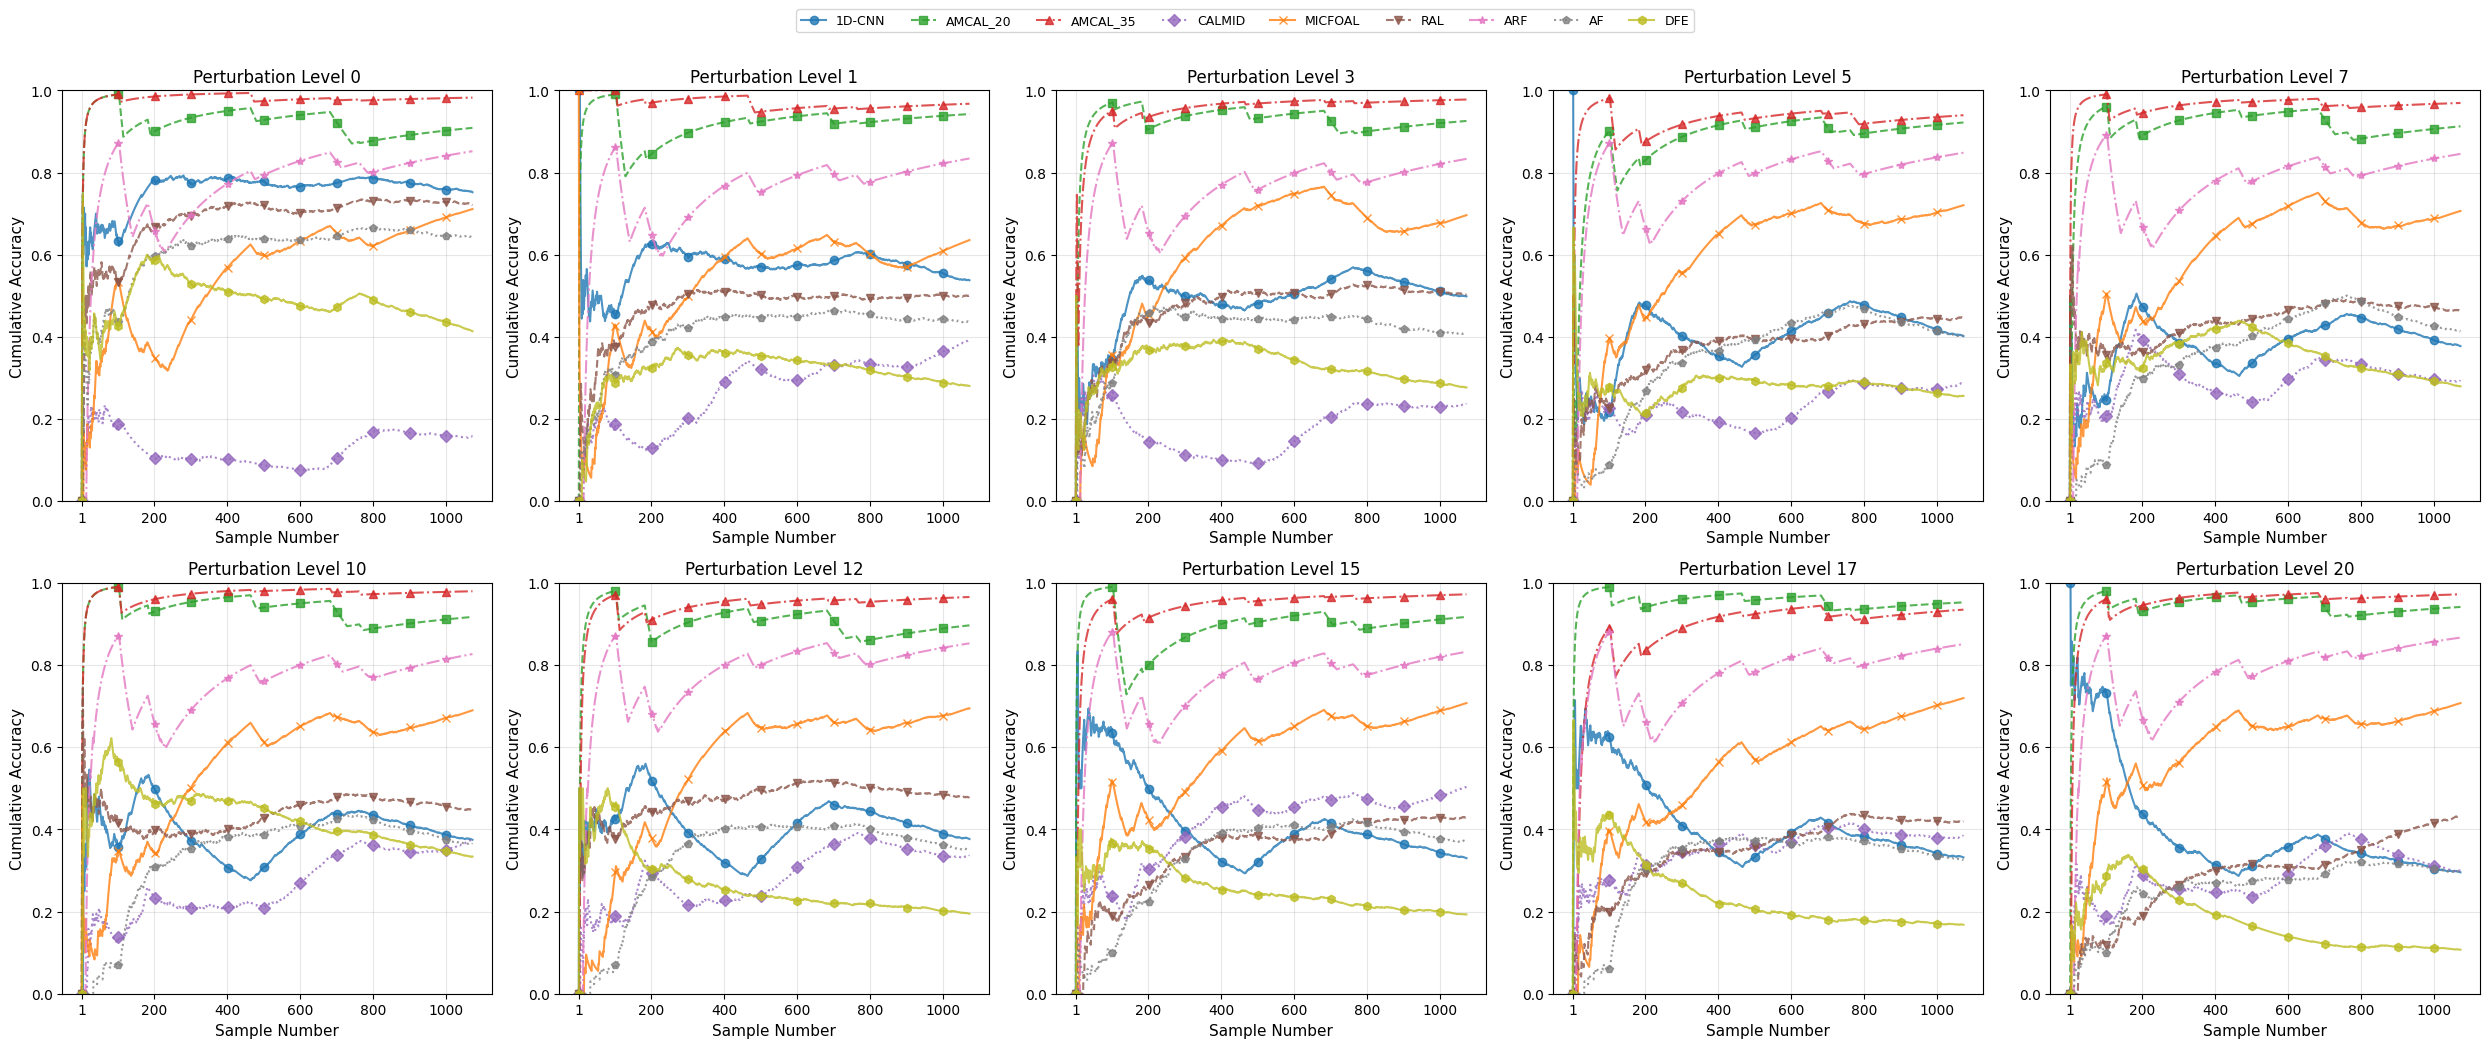

✓ Saved: Results/cumulative_accuracy_full_9methods.png


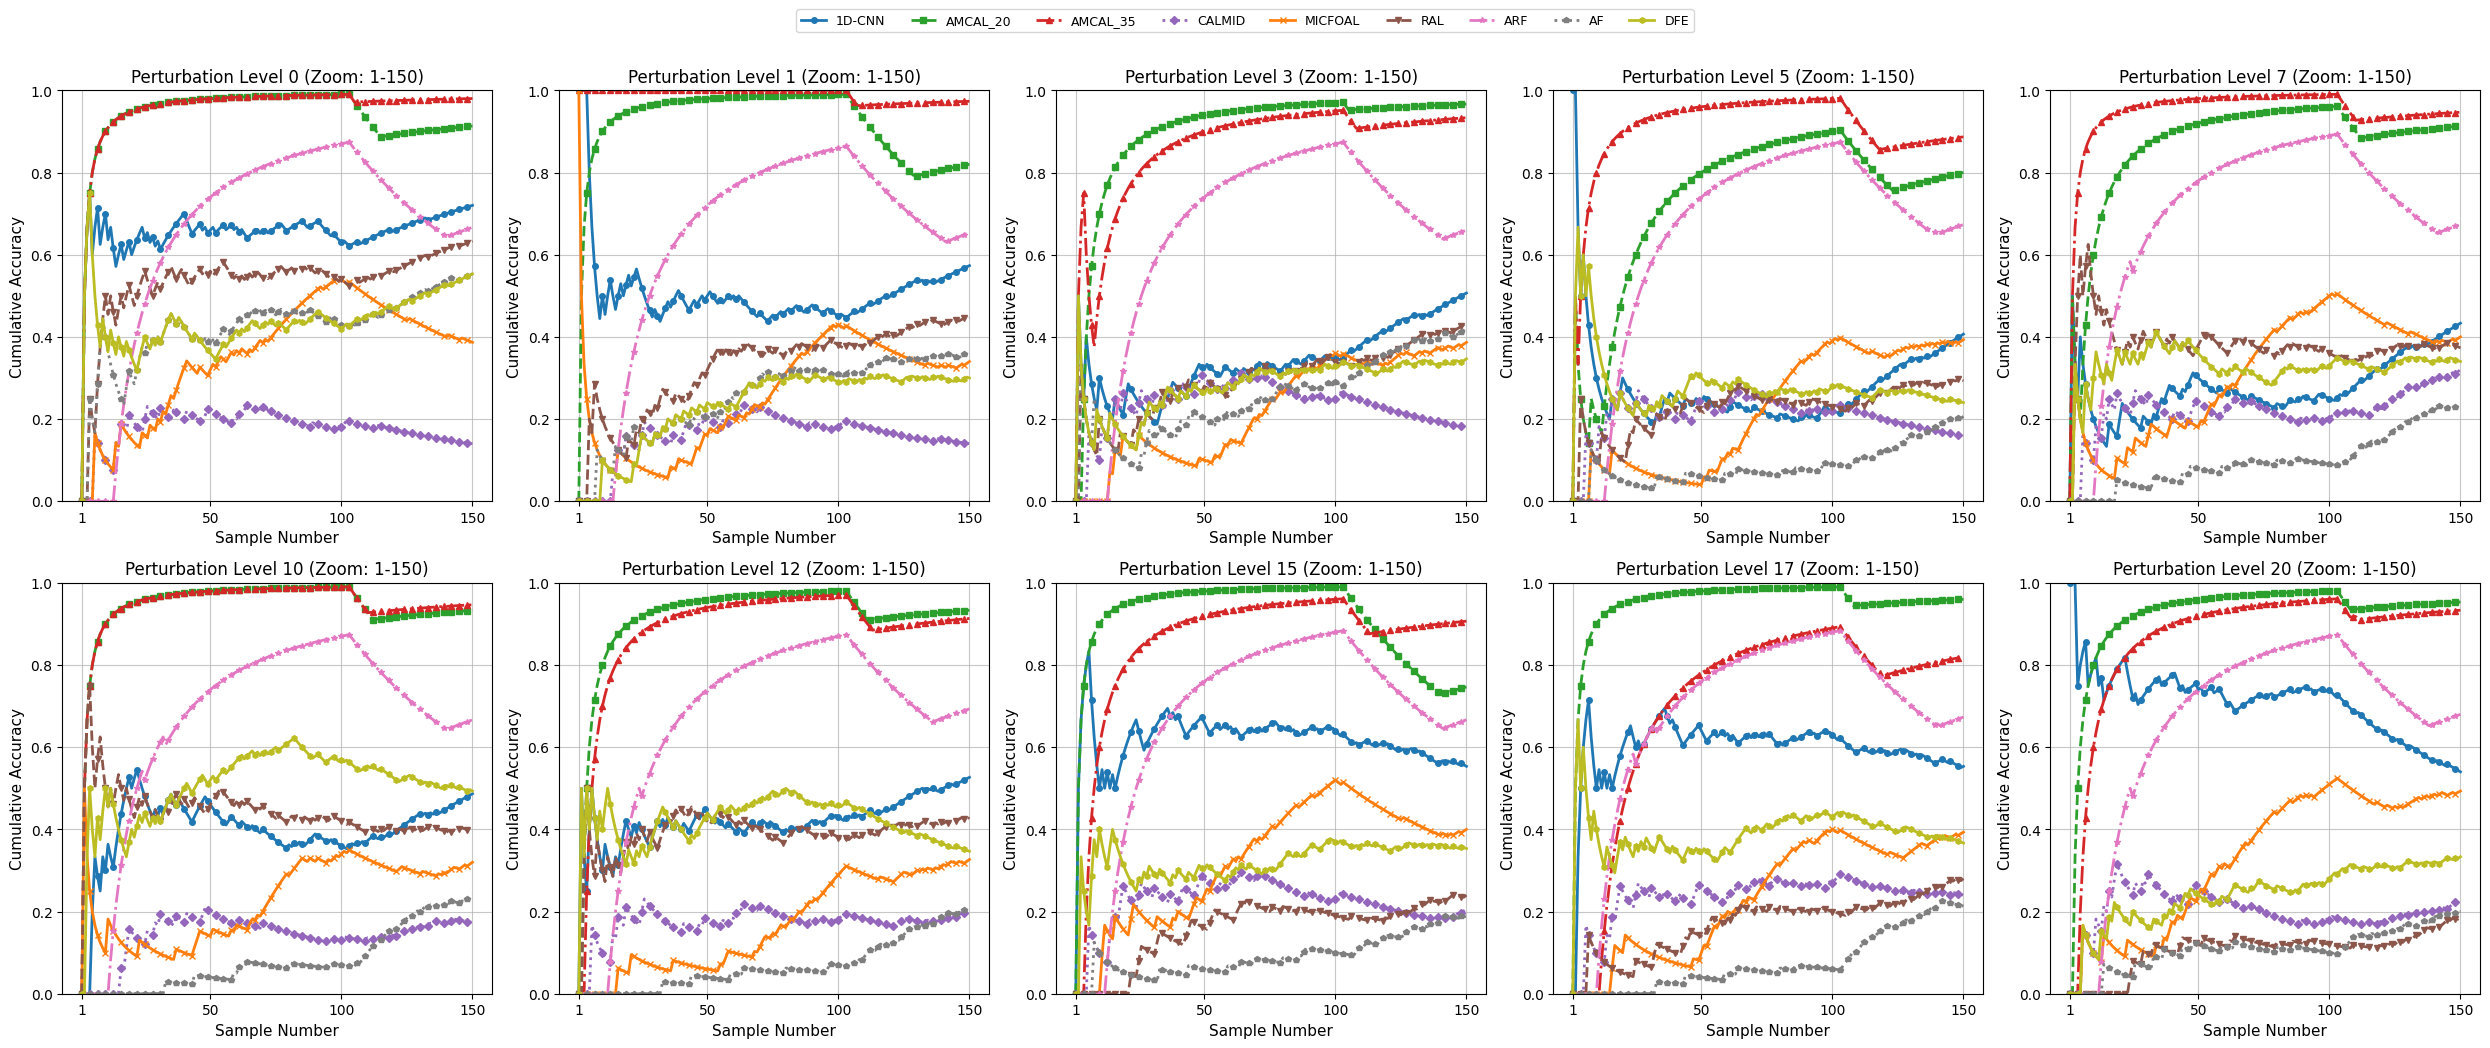

✓ Saved: Results/cumulative_accuracy_zoom_9methods.png

FINAL ACCURACIES COMPARISON


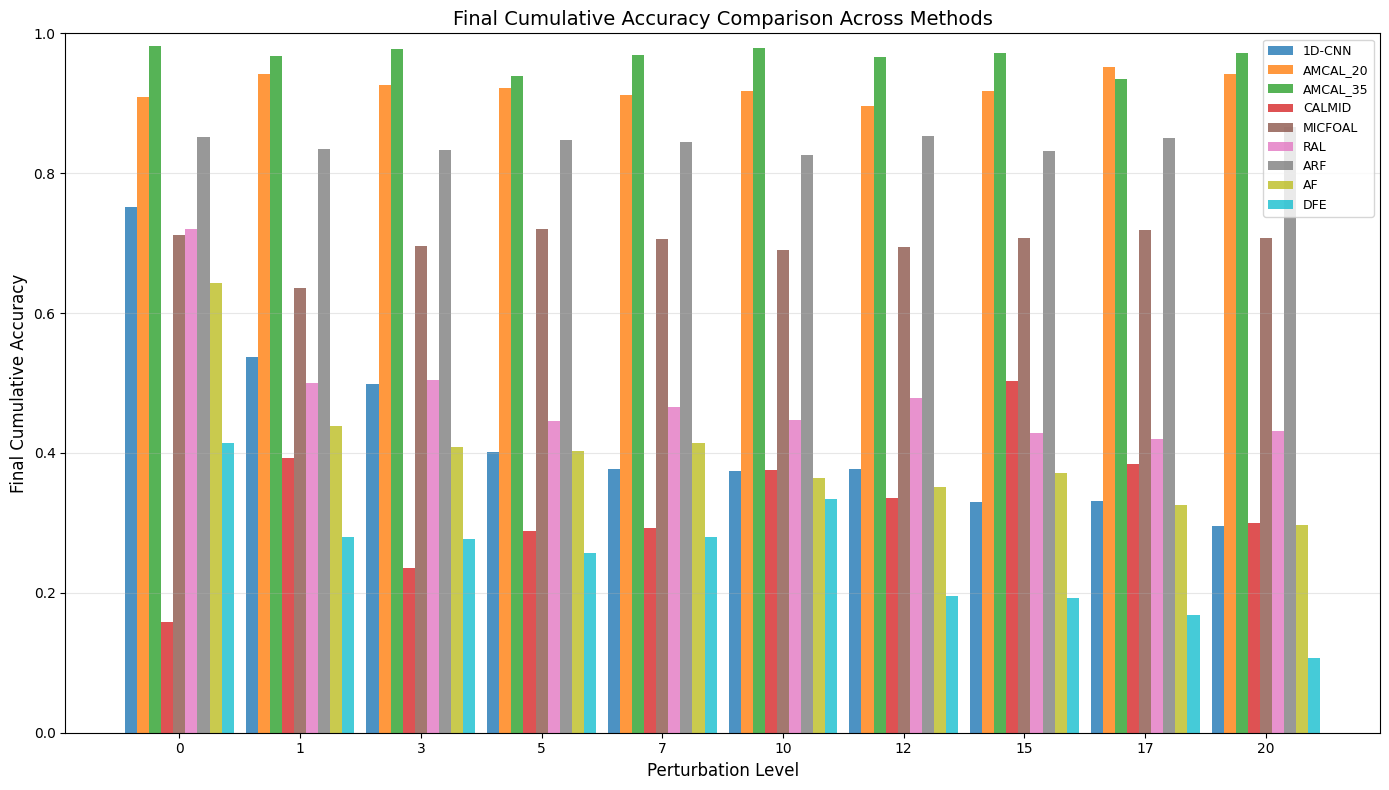

✓ Saved: Results/final_accuracies_comparison_9methods.png

SUMMARY TABLE - FINAL ACCURACIES
  Method Level 0 Level 1 Level 3 Level 5 Level 7 Level 10 Level 12 Level 15 Level 17 Level 20
  1D-CNN  0.7521  0.5377  0.4986  0.4017  0.3774   0.3747   0.3765   0.3299   0.3318   0.2954
AMCAL_20  0.9087  0.9422  0.9254  0.9217  0.9124   0.9171   0.8966   0.9171   0.9525   0.9413
AMCAL_35  0.9823  0.9674  0.9776  0.9394  0.9692   0.9795   0.9655   0.9720   0.9348   0.9720
  CALMID  0.1584  0.3924  0.2358  0.2889  0.2926   0.3756   0.3355   0.5033   0.3840   0.2992
 MICFOAL  0.7111  0.6356  0.6962  0.7204  0.7064   0.6897   0.6943   0.7074   0.7195   0.7074
     RAL  0.7204  0.4995  0.5042  0.4455  0.4651   0.4473   0.4790   0.4287   0.4194   0.4315
     ARF  0.8518  0.8341  0.8332  0.8481  0.8453   0.8267   0.8527   0.8322   0.8509   0.8667
      AF  0.6431  0.4380  0.4082  0.4026  0.4138   0.3644   0.3514   0.3719   0.3262   0.2964
     DFE  0.4138  0.2805  0.2768  0.2563  0.2796   0.3336   0.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# List of methods and file names (9 methods)
methods = [
    '1D-CNN',
    'AMCAL_20', 
    'AMCAL_35', 
    'CALMID', 
    'MICFOAL', 
    'RAL', 
    'ARF',
    'AF',      # روش AF اضافه شده
    'DFE'      # روش DFE اضافه شده
]

# File names for each method
file_names = [
    f"Results/{method}_cumulative_accuracy.csv" for method in methods
]

# Levels
levels = [0, 1, 3, 5, 7, 10, 12, 15, 17, 20]

# **Zoom range**
zoom_start = 1   # Start of zoom range
zoom_end = 150   # End of zoom range

# Read data
data = {}
missing_methods = []

print("="*60)
print("LOADING DATA")
print("="*60)

for method, file_name in zip(methods, file_names):
    if os.path.exists(file_name):
        df = pd.read_csv(file_name, index_col=0)
        data[method] = df
        print(f"✓ Loaded {method} from {file_name} (shape: {df.shape})")
    else:
        print(f"✗ Warning: {file_name} not found!")
        missing_methods.append(method)

# Remove missing methods
available_methods = [m for m in methods if m in data]
if missing_methods:
    print(f"\n⚠️ Missing methods: {missing_methods}")
    print(f"Available methods: {available_methods}")

if len(available_methods) == 0:
    print("No data files found. Exiting.")
    exit()

# Colors and styles for 9 methods (expanded)
colors = [
    '#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#ff7f0e', 
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22'
]
linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-']
markers = ['o', 's', '^', 'D', 'x', 'v', '*', 'p', 'h']

# Sample numbers (max 1073 samples)
samples = range(1, 1074)

print("\n" + "="*60)
print("PLOTTING")
print("="*60)

# **Main Figure: Full Range Plots** (2x5 = 10 subplots)
fig_main, axs_main = plt.subplots(2, 5, figsize=(25, 10), sharex=False, sharey=False)
axs_main = axs_main.flatten()

for i, level in enumerate(levels):
    ax = axs_main[i]
    
    # Plot full range for available methods
    for j, method in enumerate(available_methods):
        try:
            # Check if level exists in DataFrame
            if level in data[method].index:
                accuracies = data[method].loc[level].values
                # Trim to match samples length if needed
                if len(accuracies) > len(samples):
                    accuracies = accuracies[:len(samples)]
                ax.plot(samples[:len(accuracies)], accuracies, 
                       color=colors[j], linestyle=linestyles[j], 
                       marker=markers[j], markevery=100, 
                       linewidth=1.5, alpha=0.8, label=method)
            else:
                print(f"  Warning: Level {level} not found in {method}")
        except Exception as e:
            print(f"  Error plotting {method} at level {level}: {e}")
        
    ax.set_title(f'Perturbation Level {level}', fontsize=12)
    ax.set_xlabel('Sample Number', fontsize=11)
    ax.set_ylabel('Cumulative Accuracy', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=10)
    
    # Force numbers on axes
    ax.set_xticks([1, 200, 400, 600, 800, 1000])
    ax.set_xticklabels(['1', '200', '400', '600', '800', '1000'])
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_ylim([0, 1])

# Hide empty subplots (if any)
for i in range(len(levels), 10):
    axs_main[i].set_visible(False)

# Add legend to main figure
handles, labels = axs_main[0].get_legend_handles_labels()
fig_main.legend(handles, labels, loc='upper center', ncol=len(available_methods), 
                bbox_to_anchor=(0.5, 1.05), fontsize=9)

plt.tight_layout()
plt.savefig('Results/cumulative_accuracy_full_9methods.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: Results/cumulative_accuracy_full_9methods.png")

# **Separate Zoom Figure: Zoomed Range Plots**
fig_zoom, axs_zoom = plt.subplots(2, 5, figsize=(25, 10), sharex=False, sharey=False)
axs_zoom = axs_zoom.flatten()

# Calculate zoom range
zoom_samples = list(range(zoom_start, min(zoom_end, len(samples)) + 1))

for i, level in enumerate(levels):
    axz = axs_zoom[i]
    
    # Plot zoomed range for available methods
    for j, method in enumerate(available_methods):
        try:
            if level in data[method].index:
                accuracies = data[method].loc[level].values
                # Trim to zoom range
                zoom_accuracies = accuracies[zoom_start-1:zoom_end]
                zoom_samples_plot = samples[zoom_start-1:zoom_end]
                axz.plot(zoom_samples_plot, zoom_accuracies, 
                        color=colors[j], linestyle=linestyles[j], 
                        marker=markers[j], markersize=4, 
                        linewidth=2, markevery=3, alpha=1, label=method)
        except Exception as e:
            pass
    
    axz.set_title(f'Perturbation Level {level} (Zoom: {zoom_start}-{zoom_end})', fontsize=12)
    axz.set_xlabel('Sample Number', fontsize=11)
    axz.set_ylabel('Cumulative Accuracy', fontsize=11)
    axz.grid(True, alpha=0.7)
    axz.tick_params(labelsize=10)
    
    # Force numbers on axes for ZOOM
    axz.set_xticks([zoom_start, 50, 100, zoom_end])
    axz.set_xticklabels([str(zoom_start), '50', '100', str(zoom_end)])
    axz.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    axz.set_ylim([0, 1])

# Hide empty subplots
for i in range(len(levels), 10):
    axs_zoom[i].set_visible(False)

# Add legend to zoom figure
handles_zoom, labels_zoom = axs_zoom[0].get_legend_handles_labels()
fig_zoom.legend(handles_zoom, labels_zoom, loc='upper center', ncol=len(available_methods), 
                bbox_to_anchor=(0.5, 1.05), fontsize=9)

plt.tight_layout()
plt.savefig('Results/cumulative_accuracy_zoom_9methods.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: Results/cumulative_accuracy_zoom_9methods.png")

# **Additional: Bar Chart Comparison - Final Accuracies**
print("\n" + "="*60)
print("FINAL ACCURACIES COMPARISON")
print("="*60)

fig_bar, ax_bar = plt.subplots(figsize=(14, 8))

# Prepare data for bar chart
x = np.arange(len(levels))  # level positions
width = 0.1  # width of each bar
colors_bar = plt.cm.tab10(np.linspace(0, 1, len(available_methods)))

for idx, method in enumerate(available_methods):
    final_accuracies = []
    for level in levels:
        if level in data[method].index:
            acc_values = data[method].loc[level].values
            final_acc = acc_values[-1] if len(acc_values) > 0 else 0
            final_accuracies.append(final_acc)
        else:
            final_accuracies.append(0)
    
    bars = ax_bar.bar(x + idx * width, final_accuracies, width, 
                      label=method, color=colors_bar[idx], alpha=0.8)

ax_bar.set_xlabel('Perturbation Level', fontsize=12)
ax_bar.set_ylabel('Final Cumulative Accuracy', fontsize=12)
ax_bar.set_title('Final Cumulative Accuracy Comparison Across Methods', fontsize=14)
ax_bar.set_xticks(x + width * (len(available_methods) - 1) / 2)
ax_bar.set_xticklabels(levels)
ax_bar.legend(loc='upper right', fontsize=9)
ax_bar.grid(True, alpha=0.3, axis='y')
ax_bar.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('Results/final_accuracies_comparison_9methods.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: Results/final_accuracies_comparison_9methods.png")

# **Print summary table**
print("\n" + "="*60)
print("SUMMARY TABLE - FINAL ACCURACIES")
print("="*60)

summary_data = []
for method in available_methods:
    row = {'Method': method}
    for level in levels:
        if level in data[method].index:
            acc_values = data[method].loc[level].values
            final_acc = acc_values[-1] if len(acc_values) > 0 else np.nan
            row[f'Level {level}'] = f"{final_acc:.4f}" if not np.isnan(final_acc) else "N/A"
        else:
            row[f'Level {level}'] = "N/A"
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

# Save summary
df_summary.to_csv('Results/accuracy_summary_9methods.csv', index=False)
print("\n✓ Summary saved to: Results/accuracy_summary_9methods.csv")

print("\n" + "="*60)
print("ALL PLOTS SAVED SUCCESSFULLY!")
print("="*60)
print("\nGenerated files:")
print("  1. Results/cumulative_accuracy_full_9methods.png")
print("  2. Results/cumulative_accuracy_zoom_9methods.png")
print("  3. Results/final_accuracies_comparison_9methods.png")
print("  4. Results/accuracy_summary_9methods.csv")